In [3]:
pip install qutip

In [4]:
import warnings
import logging


warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)


Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 64 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 1.75 MiB | 8.78 MiB/s, done.
Resolving deltas: 100% (18/18), done.
===== Checking data directory =====
Fig2b_Data.zip	Phonon_gc_inv_data.npz	phonon_heatmap_data.npz  README.md
Loading pre-computed data from ./Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/phonon_heatmap_data.npz...
Data loaded successfully.
Generating Fig. 2a...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure downloaded: Fig2a_Phase_Diagram_Heatmap_2026-09-14.pdf


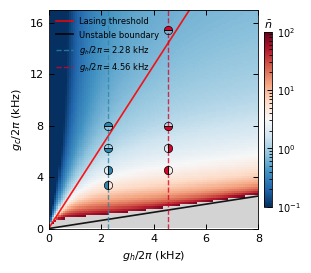

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from qutip import *
from google.colab import files
from datetime import datetime
import os
from tqdm import tqdm

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP steady-state calculation
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Global Configuration ==================
run_date = datetime.now().strftime("%Y-%m-%d")

def download_pdf(base_name):
    filename = f"{base_name}_{run_date}.pdf"
    plt.gcf().savefig(filename, format='pdf', dpi=400, bbox_inches='tight')
    try:
        files.download(filename)
        print(f"Figure downloaded: {filename}")
    except:
        print(f"Figure saved locally: {filename}")

# ================== 2. Auto-pull data from GitHub ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

print("===== Checking data directory =====")
!ls ./Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/

# ================== 3. Parameter Settings ==================
eta = 0.114
N_cutoff = 100
gammah_val, gammac_val = 15e3, 150e3
delta = 0

gh_range = np.linspace(0.1, 8, 100)
gc_range = np.linspace(0.1, 17, 100)

exp_gh_20_val = 20 * eta
exp_gc_20_pts = np.array([70, 40, 55, 30]) * eta
exp_gh_40_val = 40 * eta
exp_gc_40_pts = np.array([135, 55, 70, 40]) * eta

# ================== 4. Compute or Load Data ==================
cache_file = './Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/phonon_heatmap_data.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP steady-state calculation...")
    a = tensor(destroy(N_cutoff), qeye(3))
    g_s, eh, ec = basis(3, 0), basis(3, 1), basis(3, 2)
    smh = tensor(qeye(N_cutoff), g_s * eh.dag())
    smc = tensor(qeye(N_cutoff), g_s * ec.dag())
    n_op = a.dag() * a

    n_avg_map = np.zeros((len(gc_range), len(gh_range)))

    # 进度条包裹外层循环
    for i, gh_khz in enumerate(tqdm(gh_range, desc="Computing Phase Diagram")):
        for j, gc_khz in enumerate(gc_range):
            oh_val = 2 * np.pi * (gh_khz / eta) * 1e3
            oc_val = 2 * np.pi * (gc_khz / eta) * 1e3

            H = (0.5 * 1j * eta * oh_val * (a.dag() * smh.dag() - a * smh)
                 + 0.5 * 1j * eta * oc_val * (a.dag() * smc - a * smc.dag()))
            c_ops = [np.sqrt(gammah_val) * smh, np.sqrt(gammac_val) * smc]

            try:
                rho_ss = steadystate(H, c_ops)
                n_avg_map[j, i] = expect(n_op, rho_ss)
            except:
                n_avg_map[j, i] = np.nan

    print("\nComputation finished! (Data is kept in memory for plotting)")

else:
    print(f"Loading pre-computed data from {cache_file}...")
    if os.path.exists(cache_file):
        data = np.load(cache_file, allow_pickle=True)
        n_avg_map = data['n_avg_map']
        print("Data loaded successfully.")
    else:
        raise FileNotFoundError(f"Cannot find {cache_file}. Please set RECOMPUTE_DATA=True or check the path.")

# ================== 5. Plotting ==================
print("Generating Fig. 2a...")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 0.6,
    'lines.linewidth': 0.8,
})

fig, ax = plt.subplots(figsize=(3.0, 2.6))

# ----- 5.1 Heatmap -----
masked_n = np.ma.masked_where(n_avg_map > 80, n_avg_map)
cmap = plt.get_cmap('RdBu_r').copy()
cmap.set_bad(color='lightgray')

im = ax.pcolormesh(gh_range, gc_range, masked_n, shading='auto',
                   norm=LogNorm(vmin=1e-1, vmax=1e2),
                   cmap=cmap, rasterized=True)

# ----- 5.2 Boundary Lines -----
slope1 = np.sqrt(gammah_val / gammac_val)
slope2 = np.sqrt(gammac_val / gammah_val)

gh_line = np.linspace(0, 8, 400)
ax.plot(gh_line, gh_line * slope2, 'r-', lw=1.2, alpha=0.9, label='Lasing threshold')
ax.plot(gh_line, gh_line * slope1, 'k-', lw=1.2, alpha=0.9, label='Unstable boundary')

# ----- 5.3 Vertical Lines with Exact Labels -----
ax.axvline(x=exp_gh_20_val, color='#2E86AB', linestyle='--', lw=1.0, alpha=0.8,
           label=r'$g_h/2\pi = 2.28$ kHz')
ax.axvline(x=exp_gh_40_val, color='#D90429', linestyle='--', lw=1.0, alpha=0.8,
           label=r'$g_h/2\pi = 4.56$ kHz')

# ----- 5.4 Experimental Points: Half-filled Circles -----
fillstyles = ['left', 'right', 'bottom', 'top']
gc_20_sorted = np.sort(exp_gc_20_pts)
gc_40_sorted = np.sort(exp_gc_40_pts)

for i, gc in enumerate(gc_20_sorted):
    ax.plot(exp_gh_20_val, gc, marker='o', fillstyle=fillstyles[i],
            markersize=6, markerfacecolor='#2E86AB', markeredgecolor='black',
            markeredgewidth=0.5, linestyle='none', zorder=3)

for i, gc in enumerate(gc_40_sorted):
    ax.plot(exp_gh_40_val, gc, marker='o', fillstyle=fillstyles[i],
            markersize=6, markerfacecolor='#D90429', markeredgecolor='black',
            markeredgewidth=0.5, linestyle='none', zorder=3)

# ----- 5.5 Axes and Legend -----
ax.set_xlabel(r'$g_h/2\pi$ (kHz)')
ax.set_ylabel(r'$g_c/2\pi$ (kHz)')
ax.set_xlim(0, 8)
ax.set_ylim(0, 17)
ax.set_yticks([0, 4, 8, 12, 16])
ax.set_yticklabels(['0', '4', '8', '12', '16'], fontsize=8)
ax.legend(loc='upper left', frameon=False, fontsize=6)

# ----- 5.6 Colorbar -----
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.ax.set_title(r'$\bar{n}$', fontsize=8, pad=2)
cbar.set_ticks([1e-1, 1, 10, 100])
cbar.set_ticklabels([r'$10^{-1}$', r'$10^0$', r'$10^1$', r'$10^2$'])
cbar.ax.tick_params(labelsize=7)

plt.tight_layout(pad=0.3)

download_pdf("Fig2a_Phase_Diagram_Heatmap")
plt.show()

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 64, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 64 (delta 18), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (64/64), 1.75 MiB | 7.62 MiB/s, done.
Resolving deltas: 100% (18/18), done.


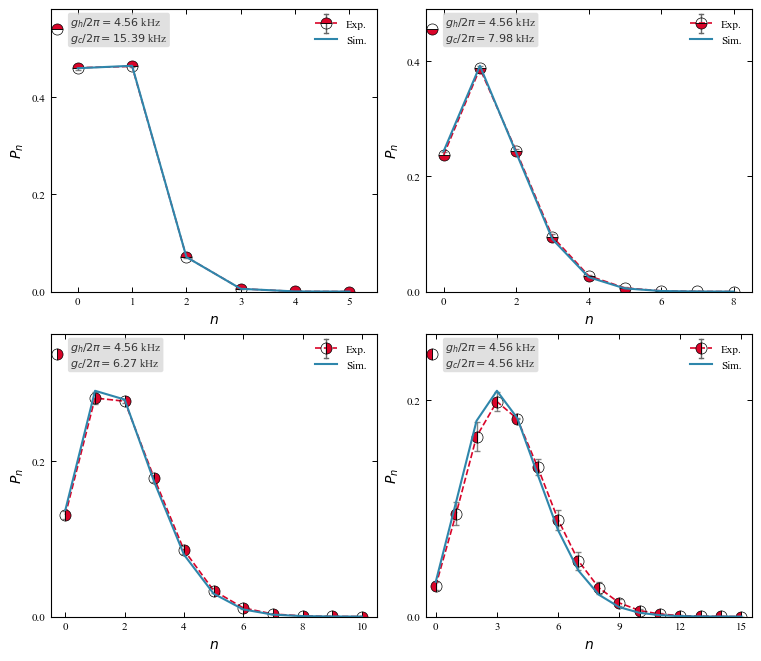

Figure saved successfully: Fig2b_Phonon_Distribution_2x2.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered successfully.


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.ticker import MultipleLocator
from matplotlib.legend_handler import HandlerBase
from google.colab import files  # For automatic download

# ================== 1. Colab Environment Preparation ==================
# Clone the repository and unzip data (Using -o to force overwrite without prompting)
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git
!unzip -o -q Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/Fig2b_Data.zip -d ./Fig2b_Data/

# Fix font warnings (Compatible with latest Matplotlib in Colab)
!wget -q "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf" -O /usr/share/fonts/truetype/Times_New_Roman.ttf
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/Times_New_Roman.ttf')

# ================== 2. Custom Legend Handler ==================
class HandlerLine2DWithError(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        x = 0.5 * width
        y = 0.5 * height
        err_len = 1.2 * height

        # Retrieve the fillstyle from the original handle to ensure consistency
        fs = orig_handle.get_fillstyle() if hasattr(orig_handle, 'get_fillstyle') else 'left'

        artists = []
        # 1. Error bar (vertical line + caps) - bottom layer
        vline = plt.Line2D([x, x], [y - err_len, y + err_len], color='#666666', lw=1.0, transform=trans)
        cap1 = plt.Line2D([x - 0.1*width, x + 0.1*width], [y - err_len, y - err_len], color='#666666', lw=1.0, transform=trans)
        cap2 = plt.Line2D([x - 0.1*width, x + 0.1*width], [y + err_len, y + err_len], color='#666666', lw=1.0, transform=trans)
        artists.extend([vline, cap1, cap2])

        # 2. Dashed line - middle layer
        dash_line = plt.Line2D([0, width], [y, y], color='#D90429', linestyle='--', lw=1.2, transform=trans)
        artists.append(dash_line)

        # 3. Half-filled marker - top layer
        marker = plt.Line2D([x], [y], marker='o', fillstyle=fs, color='#D90429',
                            markerfacecolor='#D90429', markeredgecolor='black', markersize=8,
                            markeredgewidth=0.5, linestyle='none', transform=trans)
        artists.append(marker)
        return artists

# ================== 3. General Plotting Function ==================
def plot_phonon_distribution(dataset_name, ax, n_max, xticks, fillstyle, gh_label, gc_label):
    """
    Reads the Excel results generated by MATLAB and plots the phonon distribution.
    """
    excel_file = f'./Fig2b_Data/Fig2b_Data/Analysis_Result/Final_Analysis_Report_{dataset_name}.xlsx'

    if not os.path.exists(excel_file):
        print(f"Warning: File not found {excel_file}")
        return

    df_pn = pd.read_excel(excel_file, sheet_name='Pn_Full_Data')

    n_all = df_pn['n'].values
    Pn_fit_all = df_pn['Pn_Exp_Fit'].values
    Pn_err_all = df_pn['Pn_Error_Scaled_for_Plot'].values
    Pn0_theory_all = df_pn['Pn_Theory'].values

    # Truncate data based on the specific n_max for this dataset
    mask = n_all <= n_max
    n_list = n_all[mask]
    Pn_fit = Pn_fit_all[mask]
    Pn_err_plot = Pn_err_all[mask]
    Pn0_theory = Pn0_theory_all[mask]

    # Plot experimental data with error bars and specific semi-filled markers
    ax.errorbar(n_list, Pn_fit, yerr=Pn_err_plot, fmt='none', ecolor='#666666',
                elinewidth=1.0, capsize=2.0, capthick=1.0, alpha=0.8)
    ax.plot(n_list, Pn_fit, 'o--', color='#D90429', markerfacecolor='#D90429',
            markeredgecolor='black', fillstyle=fillstyle, markersize=8,
            markeredgewidth=0.5, linewidth=1.2, label='Exp.')

    # Plot theoretical simulation curve
    ax.plot(n_list, Pn0_theory, '-', color='#2E86AB', linewidth=1.5, label='Sim.')

    # Axis configurations
    ax.set_xlabel('$n$')
    ax.set_ylabel('$P_n$')
    ax.set_xlim(-0.5, n_max + 0.5)

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks], fontsize=8)
    else:
        ax.tick_params(axis='x', labelsize=8)

    max_y = max(np.max(Pn_fit), np.max(Pn0_theory))
    ax.set_ylim(0, max_y * 1.25)
    ax.yaxis.set_major_locator(MultipleLocator(0.2))

    # Custom Legend
    exp_handle = plt.Line2D([], [], color='#D90429', marker='o', fillstyle=fillstyle,
                            markerfacecolor='#D90429', markeredgecolor='black',
                            markersize=8, markeredgewidth=0.5, linestyle='--', linewidth=1.2)
    sim_handle = plt.Line2D([], [], color='#2E86AB', linewidth=1.5, linestyle='-')
    ax.legend([exp_handle, sim_handle], ['Exp.', 'Sim.'], loc='upper right',
              frameon=False, fontsize=8, handler_map={exp_handle: HandlerLine2DWithError()})

    # Parameter annotation box
    ax.plot(0.02, 0.93, marker='o', fillstyle=fillstyle, color='#D90429',
            markerfacecolor='#D90429', markeredgecolor='black',
            markersize=8, markeredgewidth=0.5, linestyle='none',
            transform=ax.transAxes, clip_on=False)
    ax.text(0.06, 0.98, f'{gh_label}\n{gc_label}', transform=ax.transAxes,
            fontsize=8, va='top', ha='left', color='#333333',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgray', edgecolor='none', alpha=0.7))

# ================== 4. Main Execution ==================
if __name__ == "__main__":
    # Global Plotting Style
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.labelsize': 10,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'axes.linewidth': 0.8,
        'lines.linewidth': 1.2,
    })

    # Configuration for the four main text datasets
    # Please double-check the physical labels (gh, gc) for each dataset
    configs = {
        'B1': {'n_max': 5,  'xticks': [0, 1, 2, 3, 4, 5], 'fillstyle': 'top',    'gh': r'$g_h/2\pi = 4.56$ kHz', 'gc': r'$g_c/2\pi = 15.39$ kHz'},
        'B2': {'n_max': 10, 'xticks': [0, 2, 4, 6, 8, 10], 'fillstyle': 'right',  'gh': r'$g_h/2\pi = 4.56$ kHz', 'gc': r'$g_c/2\pi = 6.27$ kHz'},
        'B3': {'n_max': 8,  'xticks': [0, 2, 4, 6, 8],     'fillstyle': 'bottom', 'gh': r'$g_h/2\pi = 4.56$ kHz', 'gc': r'$g_c/2\pi = 7.98$ kHz'},
        'B4': {'n_max': 15, 'xticks': [0, 3, 6, 9, 12, 15],'fillstyle': 'left',   'gh': r'$g_h/2\pi = 4.56$ kHz', 'gc': r'$g_c/2\pi = 4.56$ kHz'}
    }

    # Define the 2x2 grid layout according to the user's request:
    # Top row: B1 (gc=15.39) and B3 (gc=7.98)
    # Bottom row: B2 (gc=6.27) and B4 (gc=4.56)
    grid_layout = [
        ['B1', 'B3'],
        ['B2', 'B4']
    ]

    # Create a 2x2 figure (Adjust figsize for a balanced aspect ratio)
    fig, axes = plt.subplots(2, 2, figsize=(7.5, 6.5), constrained_layout=True)

    for i in range(2):
        for j in range(2):
            ds = grid_layout[i][j]
            cfg = configs[ds]
            plot_phonon_distribution(
                dataset_name=ds,
                ax=axes[i, j],
                n_max=cfg['n_max'],
                xticks=cfg['xticks'],
                fillstyle=cfg['fillstyle'],
                gh_label=cfg['gh'],
                gc_label=cfg['gc']
            )

    # Save the combined 2x2 figure
    output_pdf = 'Fig2b_Phonon_Distribution_2x2.pdf'
    plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Figure saved successfully: {output_pdf}")

    # Trigger automatic download in Google Colab
    try:
        files.download(output_pdf)
        print("Download triggered successfully.")
    except Exception as e:
        print("Automatic download failed (likely not running in Colab). You can download the file manually from the file browser.")

Cloning into 'Single-ion-phonon-laser-sensing'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 59 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 1.52 MiB | 6.07 MiB/s, done.
Resolving deltas: 100% (16/16), done.
===== Checking data directory =====
Phonon_gc_inv_data.npz	phonon_heatmap_data.npz  README.md
RECOMPUTE_DATA is True. Running full QuTiP steady-state calculation...
--> Running QuTiP steadystate matrix inversion and analytical scan...
Progress: [####################] 160/160 (100.0%)
--> Computation finished.
--> Data saved to Phonon_gc_inv_data_20260914.npz
Generating Fig. 2c...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Figure downloaded: Fig2c_MeanPhonon_vs_inv_gc_2026-09-14.pdf


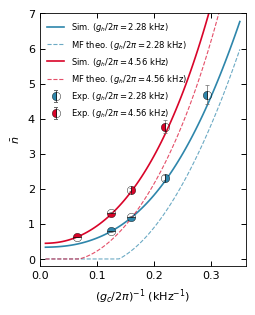

In [7]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from qutip import *
from google.colab import files
from datetime import datetime
import pandas as pd

# ==============================================================================
# USER CONFIGURATION:
# Set RECOMPUTE_DATA = False to load the pre-computed .npz file and instantly
# reproduce the figure (recommended for quick review).
# Set RECOMPUTE_DATA = True to run the full QuTiP steady-state calculation
# from scratch (may take several minutes).
# ==============================================================================
RECOMPUTE_DATA = False

# ================== 1. Global Configuration ==================
run_date = datetime.now().strftime("%Y-%m-%d")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 6,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "lines.linewidth": 1.2
})

def download_pdf(base_name):
    filename = f"{base_name}_{run_date}.pdf"
    plt.gcf().savefig(filename, format='pdf', dpi=600, bbox_inches='tight')
    try:
        files.download(filename)
        print(f"Figure downloaded: {filename}")
    except:
        print(f"Figure saved locally: {filename}")

# ================== 2. Auto-pull data from GitHub ==================
!rm -rf Single-ion-phonon-laser-sensing
!git clone https://github.com/lipeidong1999/Single-ion-phonon-laser-sensing.git

print("===== Checking data directory =====")
!ls ./Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/

# ================== 3. Physics Parameters and Analytical Formula ==================
eta = 0.114
N_cutoff = 60
gammah_val, gammac_val = 15e3, 150e3

def theoretical_n_formula(Omega_h, Omega_c, eta, gh_decay, gc_decay):
    gh = eta * Omega_h
    gc = eta * Omega_c
    num = (gc_decay + gh_decay) * ((gh**2 / gh_decay) - (gc**2 / gc_decay))
    den = ((gc**2 / gh_decay) - (gh**2 / gc_decay)) * ((gh**2 / gh_decay) + (gc**2 / gc_decay))
    if abs(den) < 1e-20:
        return 0
    res = num / den
    return res if res > 0 else 0

# ================== 4. Compute or Load Data ==================
cache_file = './Single-ion-phonon-laser-sensing/experimental_data/Fig2_data/Phonon_gc_inv_data.npz'

if RECOMPUTE_DATA:
    print("RECOMPUTE_DATA is True. Running full QuTiP steady-state calculation...")

    # Experimental data points (kHz)
    exp_Omegac_20 = np.array([70, 40, 55, 30])
    exp_n_20 = np.array([0.793, 2.319, 1.200, 4.686])
    exp_err_20 = np.array([0.013, 0.063, 0.027, 0.277])
    exp_Omegac_40 = np.array([135, 55, 70, 40])
    exp_n_40 = np.array([0.623, 1.974, 1.313, 3.773])
    exp_err_40 = np.array([0.007, 0.049, 0.027, 0.183])

    inv_gc_plot = np.linspace(0.01, 0.35, 80)
    Omegac_plot_khz = (1.0 / inv_gc_plot) / eta

    results = {}
    scan_line_frequencies = [20, 40]
    total_points = len(scan_line_frequencies) * len(Omegac_plot_khz)
    current_point = 0

    print("--> Running QuTiP steadystate matrix inversion and analytical scan...")
    for oh_khz in scan_line_frequencies:
        sim_n, theo_n = [], []
        oh_val = 2 * np.pi * oh_khz * 1e3

        a = tensor(destroy(N_cutoff), qeye(3))
        g_s, eh, ec = basis(3, 0), basis(3, 1), basis(3, 2)
        smh, smc = tensor(qeye(N_cutoff), g_s * eh.dag()), tensor(qeye(N_cutoff), g_s * ec.dag())
        n_op = a.dag() * a

        for oc_khz in Omegac_plot_khz:
            current_point += 1
            oc_val = 2 * np.pi * oc_khz * 1e3

            theo_n.append(theoretical_n_formula(oh_val, oc_val, eta, gammah_val, gammac_val))

            H = (0.5 * 1j * eta * oh_val * (a.dag() * smh.dag() - a * smh)
                 + 0.5 * 1j * eta * oc_val * (a.dag() * smc - a * smc.dag()))
            rho_ss = steadystate(H, [np.sqrt(gammah_val) * smh, np.sqrt(gammac_val) * smc])
            sim_n.append(expect(n_op, rho_ss))

            progress = current_point / total_points
            sys.stdout.write(f"\rProgress: [{int(progress*20)*'#'}{(20-int(progress*20))*'-'}] {current_point}/{total_points} ({progress*100:.1f}%)")
            sys.stdout.flush()

        results[oh_khz] = {'sim': sim_n, 'theo': theo_n}
    print("\n--> Computation finished.")

    # Generate data arrays for plotting and saving
    exp_Oh_20 = np.full_like(exp_Omegac_20, 20)
    exp_Oh_40 = np.full_like(exp_Omegac_40, 40)

    sim_data = {oh: results[oh]['sim'] for oh in [20, 40]}
    theo_data = {oh: results[oh]['theo'] for oh in [20, 40]}

    # Save to npz
    npz_save_name = f"Phonon_gc_inv_data_{run_date.replace('-', '')}.npz"
    np.savez(npz_save_name,
             inv_gc_plot=inv_gc_plot, oh_frequencies=[20, 40],
             sim_data=sim_data, theo_data=theo_data,
             exp_Oh_20=exp_Oh_20, exp_Omegac_20=exp_Omegac_20, exp_n_20=exp_n_20, exp_err_20=exp_err_20,
             exp_Oh_40=exp_Oh_40, exp_Omegac_40=exp_Omegac_40, exp_n_40=exp_n_40, exp_err_40=exp_err_40,
             run_date=run_date, gammah_val=gammah_val, gammac_val=gammac_val, eta=eta)
    print(f"--> Data saved to {npz_save_name}")

else:
    print(f"Loading pre-computed data from {cache_file}...")
    if os.path.exists(cache_file):
        data = np.load(cache_file, allow_pickle=True)
        inv_gc_plot = data['inv_gc_plot']
        sim_data = data['sim_data'].item()
        theo_data = data['theo_data'].item()
        exp_Oh_20 = data['exp_Oh_20']
        exp_Omegac_20 = data['exp_Omegac_20']
        exp_n_20 = data['exp_n_20']
        exp_err_20 = data['exp_err_20']
        exp_Oh_40 = data['exp_Oh_40']
        exp_Omegac_40 = data['exp_Omegac_40']
        exp_n_40 = data['exp_n_40']
        exp_err_40 = data['exp_err_40']
        eta = data['eta']
        print("Data loaded successfully.")
    else:
        raise FileNotFoundError(f"Cannot find {cache_file}. Please set RECOMPUTE_DATA=True or check the path.")

# ================== 5. Custom Legend Handler ==================
class HandlerLine2DWithError(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        x = 0.5 * width
        y = 0.5 * height
        err_len = 1 * height

        artists = []
        vline = plt.Line2D([x, x], [y - err_len, y + err_len],
                           color='#666666', lw=0.7, transform=trans)
        artists.append(vline)
        cap1 = plt.Line2D([x - 0.1*width, x + 0.1*width], [y - err_len, y - err_len],
                          color='#666666', lw=0.7, transform=trans)
        cap2 = plt.Line2D([x - 0.1*width, x + 0.1*width], [y + err_len, y + err_len],
                          color='#666666', lw=0.7, transform=trans)
        artists.append(cap1)
        artists.append(cap2)

        marker = plt.Line2D([x], [y], marker='o', fillstyle='left',
                            color=orig_handle.get_color(),
                            markerfacecolor=orig_handle.get_color(),
                            markeredgecolor='black', markersize=6,
                            markeredgewidth=0.3, linestyle='none',
                            transform=trans)
        artists.append(marker)
        return artists

# ================== 6. Plotting ==================
print("Generating Fig. 2c...")
fig, ax = plt.subplots(figsize=(2.4, 3.0))

color_20 = '#2E86AB'
color_40 = '#D90429'

# Plot theoretical/simulation lines
for oh, color in [(20, color_20), (40, color_40)]:
    gh = oh * 0.114
    ax.plot(inv_gc_plot, sim_data[oh], '-', color=color, lw=1.2, label=rf'$g_h/2\pi = {gh:.2f}$ kHz (sim.)')
    ax.plot(inv_gc_plot, theo_data[oh], '--', color=color, lw=0.8, alpha=0.7, label=rf'$g_h/2\pi = {gh:.2f}$ kHz (theory)')

# Plot experimental points with half-filled circles and error bars
fillstyles = ['left', 'right', 'bottom', 'top']

# Omega_h = 20
idx_20 = np.argsort(exp_Omegac_20)
Omegac_20_sorted = exp_Omegac_20[idx_20]
n_20_sorted = exp_n_20[idx_20]
err_20_sorted = exp_err_20[idx_20]
x_20_sorted = 1.0 / (eta * Omegac_20_sorted)

for i, (x, n, err) in enumerate(zip(x_20_sorted, n_20_sorted, err_20_sorted)):
    ax.errorbar(x, n, yerr=err, fmt='none', ecolor='#666666', elinewidth=0.6, capsize=1.5, capthick=0.6, alpha=0.8, zorder=2)
    ax.plot(x, n, marker='o', fillstyle=fillstyles[i], color=color_20, markerfacecolor=color_20, markeredgecolor='black', markersize=6, markeredgewidth=0.3, linestyle='none', zorder=3)

# Omega_h = 40
idx_40 = np.argsort(exp_Omegac_40)
Omegac_40_sorted = exp_Omegac_40[idx_40]
n_40_sorted = exp_n_40[idx_40]
err_40_sorted = exp_err_40[idx_40]
x_40_sorted = 1.0 / (eta * Omegac_40_sorted)

for i, (x, n, err) in enumerate(zip(x_40_sorted, n_40_sorted, err_40_sorted)):
    ax.errorbar(x, n, yerr=err, fmt='none', ecolor='#666666', elinewidth=0.6, capsize=1.5, capthick=0.6, alpha=0.8, zorder=2)
    ax.plot(x, n, marker='o', fillstyle=fillstyles[i], color=color_40, markerfacecolor=color_40, markeredgecolor='black', markersize=6, markeredgewidth=0.3, linestyle='none', zorder=3)

# Legend
handles = [
    Line2D([0], [0], color=color_20, lw=1.2, linestyle='-', label=r'Sim. ($g_h/2\pi = 2.28$ kHz)'),
    Line2D([0], [0], color=color_20, lw=0.8, linestyle='--', alpha=0.7, label=r'MF theo. ($g_h/2\pi = 2.28$ kHz)'),
    Line2D([0], [0], color=color_40, lw=1.2, linestyle='-', label=r'Sim. ($g_h/2\pi = 4.56$ kHz)'),
    Line2D([0], [0], color=color_40, lw=0.8, linestyle='--', alpha=0.7, label=r'MF theo. ($g_h/2\pi = 4.56$ kHz)'),
    Line2D([0], [0], marker='o', color=color_20, linestyle='None', markerfacecolor=color_20, markeredgecolor='black', markersize=6, markeredgewidth=0.3, label=r'Exp. ($g_h/2\pi=2.28$ kHz)'),
    Line2D([0], [0], marker='o', color=color_40, linestyle='None', markerfacecolor=color_40, markeredgecolor='black', markersize=6, markeredgewidth=0.3, label=r'Exp. ($g_h/2\pi=4.56$ kHz)')
]

handler_map = {handles[4]: HandlerLine2DWithError(), handles[5]: HandlerLine2DWithError()}
ax.legend(handles=handles, handler_map=handler_map, loc='upper left', frameon=False, fontsize=6)

ax.set_xlabel(r'$(g_c/2\pi)^{-1}$ (kHz$^{-1}$)')
ax.set_ylabel(r'$\bar{n}$')
ax.set_xlim(0, 0.36)
ax.set_ylim(-0.2, 7.0)

plt.tight_layout(pad=0.2)
download_pdf("Fig2c_MeanPhonon_vs_inv_gc")
plt.show()